In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Load Dataset

In [2]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


Dataset Overview

In [3]:
print("Dataset Shape:")
print(fraud_df.shape)

Dataset Shape:
(151112, 11)


In [4]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [5]:
fraud_df.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


Check Missing Values

In [6]:
missing_values = fraud_df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [7]:
fraud_df.isnull().sum().sort_values(ascending=False)

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Check Duplicates

In [8]:
duplicate_count = fraud_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
if duplicate_count > 0:
    fraud_df = fraud_df.drop_duplicates()

print("New Shape:", fraud_df.shape)

New Shape: (151112, 11)


Correct Data Types

In [10]:
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])

fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

In [11]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


Target Variable Analysis

In [12]:
fraud_df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [13]:
fraud_df['class'].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

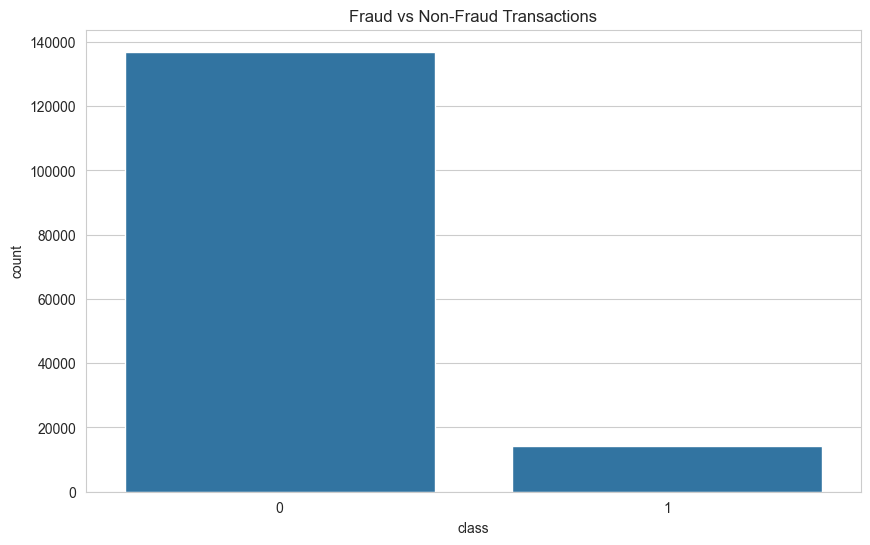

In [14]:
sns.countplot(
    x='class',
    data=fraud_df
)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

Save the Progress

In [15]:
fraud_df.to_csv(
    "../data/processed/fraud_cleaned.csv",
    index=False
)

Numerical Features Distribution

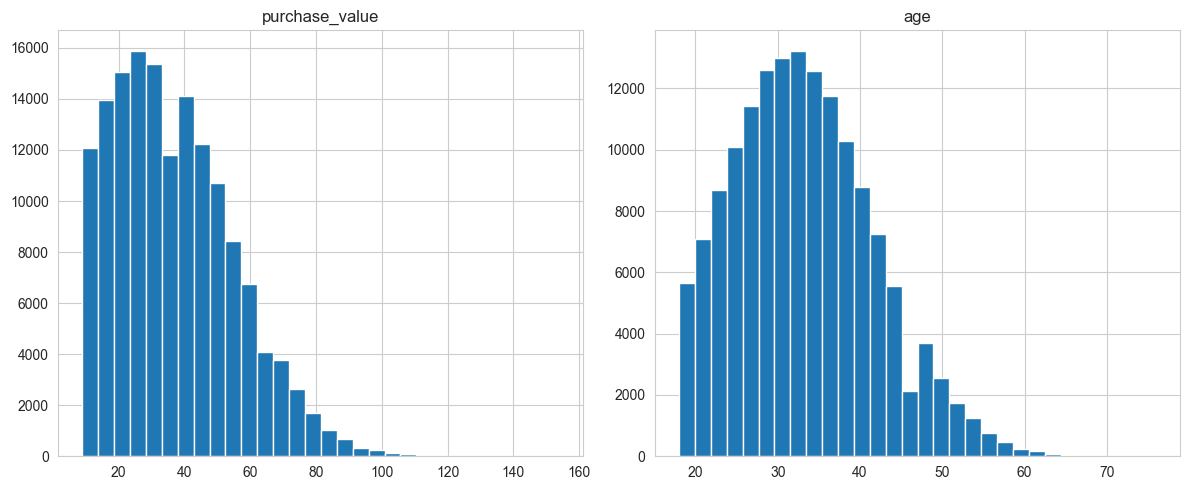

In [16]:
numerical_cols = [
    'purchase_value',
    'age'
]

fraud_df[numerical_cols].hist(
    bins=30,
    figsize=(12,5)
)

plt.tight_layout()
plt.show()

Boxplots for Outlier Detection

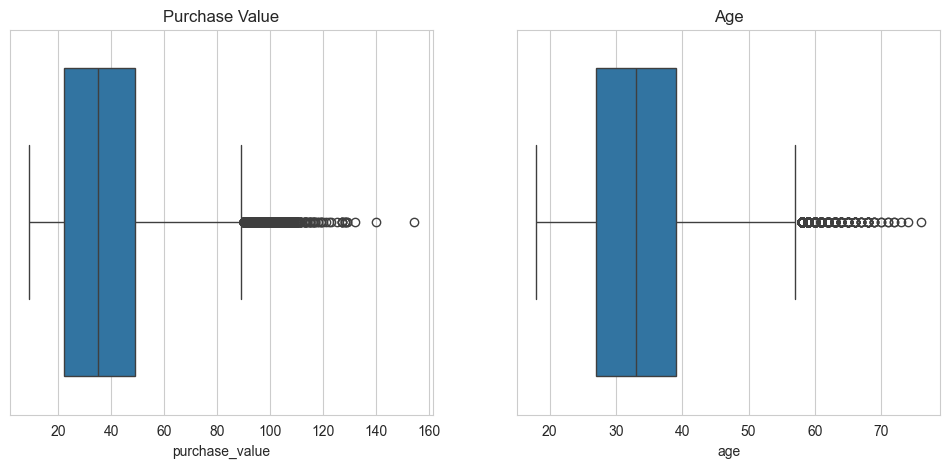

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=fraud_df['purchase_value'])
plt.title("Purchase Value")

plt.subplot(1,2,2)
sns.boxplot(x=fraud_df['age'])
plt.title("Age")

plt.show()

Categorical Feature Analysis

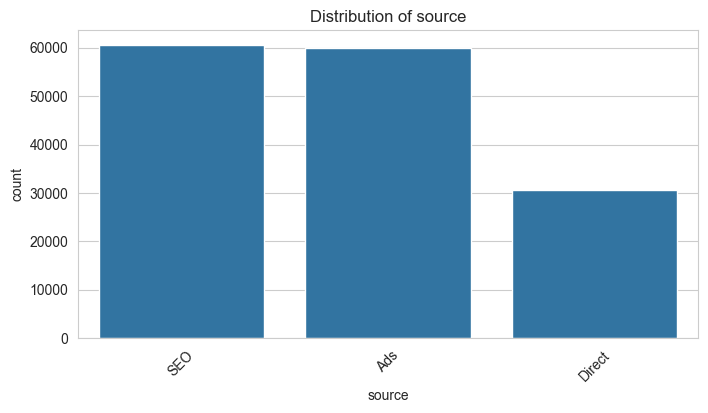

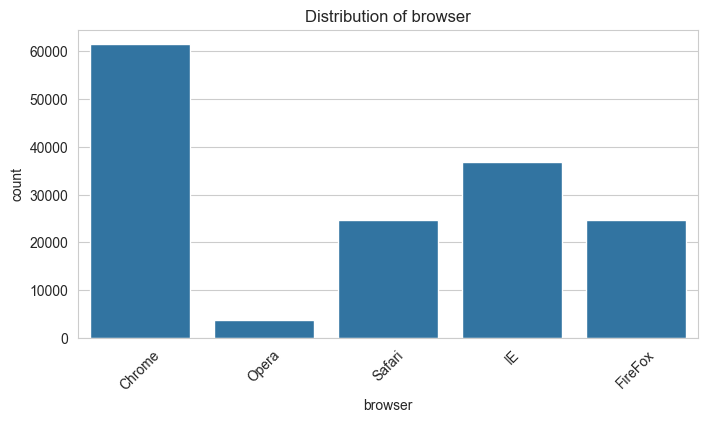

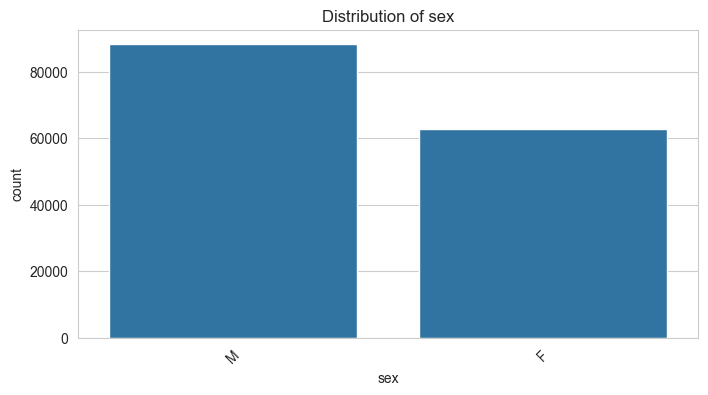

In [18]:
categorical_cols = [
    'source',
    'browser',
    'sex'
]

for col in categorical_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.countplot(
        data=fraud_df,
        x=col
    )
    
    plt.title(f"Distribution of {col}")
    
    plt.xticks(rotation=45)
    
    plt.show()

Fraud Rate by Category

In [19]:
fraud_by_source = pd.crosstab(
    fraud_df['source'],
    fraud_df['class'],
    normalize='index'
)

fraud_by_source

class,0,1
source,,
Ads,0.907934,0.092066
Direct,0.894630,0.105370
SEO,0.910715,0.089285


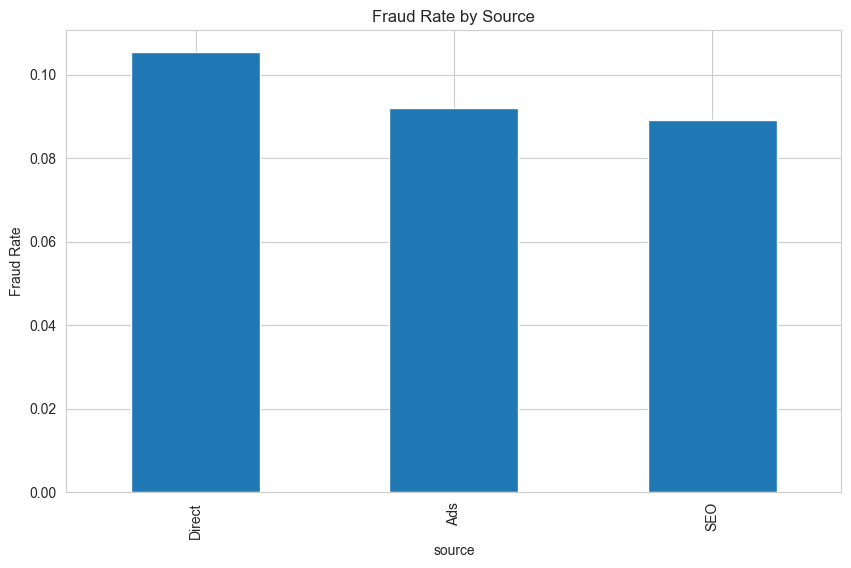

In [20]:
fraud_by_source[1].sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Source")

plt.show()

In [21]:
fraud_by_browser = pd.crosstab(
    fraud_df['browser'],
    fraud_df['class'],
    normalize='index'
)

fraud_by_browser

class,0,1
browser,,
Chrome,0.901208,0.098792
FireFox,0.904835,0.095165
IE,0.913225,0.086775
Opera,0.910773,0.089227
Safari,0.909799,0.090201


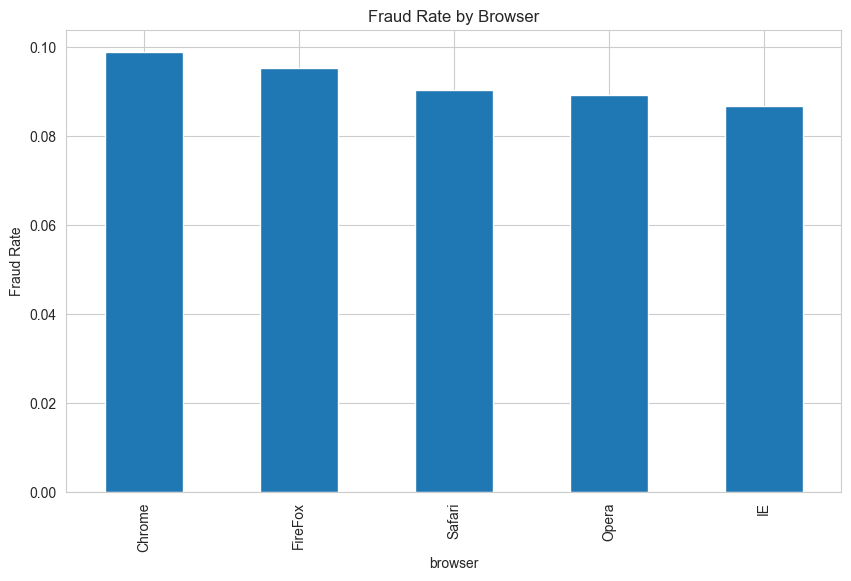

In [22]:
fraud_by_browser[1].sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Browser")

plt.show()

Fraud Rate by Gender

In [23]:
pd.crosstab(
    fraud_df['sex'],
    fraud_df['class'],
    normalize='index'
)

class,0,1
sex,,
F,0.908993,0.091007
M,0.904477,0.095523


Correlation Analysis

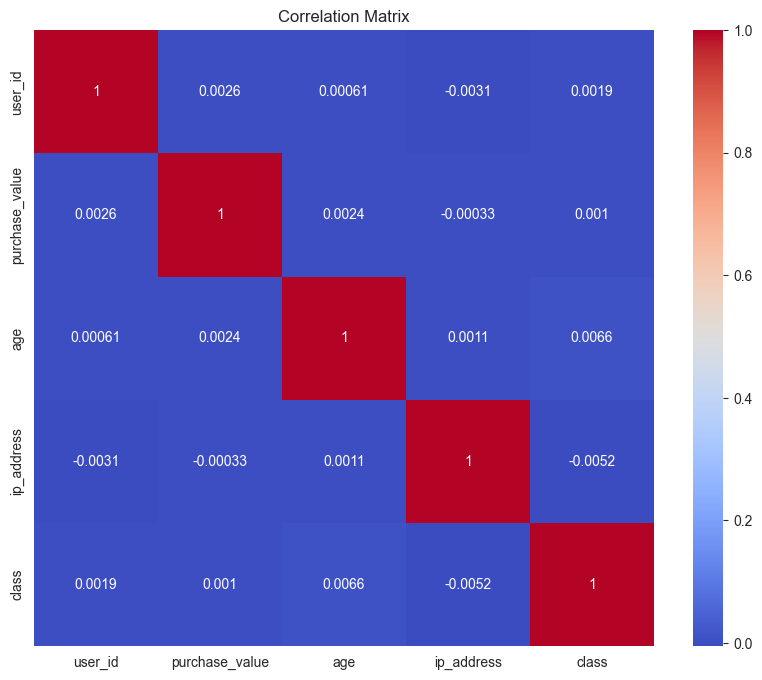

In [24]:
corr = fraud_df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Save EDA Output

In [25]:
fraud_df.to_csv(
    "../data/processed/fraud_eda_complete.csv",
    index=False
)

In [26]:
fraud_df.to_csv(
    "../data/processed/fraud_eda_complete.csv",
    index=False
)

print("EDA dataset saved successfully")

EDA dataset saved successfully


In [27]:
print(fraud_df.shape)

(151112, 11)


In [28]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


In [29]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [30]:
fraud_df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

Geolocation Integration

Load IP-to-Country Dataset

In [31]:
ip_country_df = pd.read_csv(
    "../data/raw/IpAddress_to_Country.csv"
)

ip_country_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,100000000,149999999,United States
1,150000000,199999999,Canada
2,200000000,249999999,United Kingdom
3,250000000,299999999,Germany
4,300000000,349999999,France


Inspect Dataset

In [32]:
print(ip_country_df.shape)

ip_country_df.info()

(8, 3)
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   lower_bound_ip_address  8 non-null      int64
 1   upper_bound_ip_address  8 non-null      int64
 2   country                 8 non-null      str  
dtypes: int64(2), str(1)
memory usage: 324.0 bytes


Check Missing Values

In [33]:
ip_country_df.isnull().sum()

lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64

In [34]:
print(ip_country_df.shape)

(8, 3)


In [35]:
ip_country_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   lower_bound_ip_address  8 non-null      int64
 1   upper_bound_ip_address  8 non-null      int64
 2   country                 8 non-null      str  
dtypes: int64(2), str(1)
memory usage: 324.0 bytes


In [36]:
ip_country_df

,lower_bound_ip_address,upper_bound_ip_address,country
0,100000000,149999999,United States
1,150000000,199999999,Canada
2,200000000,249999999,United Kingdom
3,250000000,299999999,Germany
4,300000000,349999999,France
5,350000000,399999999,Brazil
6,400000000,449999999,India
7,450000000,499999999,Australia


Convert IP Address to Integer

In [37]:
fraud_df['ip_address_int'] = fraud_df['ip_address'].astype('int64')

fraud_df[['ip_address', 'ip_address_int']].head()

,ip_address,ip_address_int
0,7.327584e+08,732758368
1,3.503114e+08,350311387
2,2.621474e+09,2621473820
3,3.840542e+09,3840542443
4,4.155831e+08,415583117


Create Country Lookup Function

In [38]:
def get_country(ip):
    match = ip_country_df[
        (ip_country_df['lower_bound_ip_address'] <= ip) &
        (ip_country_df['upper_bound_ip_address'] >= ip)
    ]
    
    if len(match) > 0:
        return match.iloc[0]['country']
    
    return "Unknown"

Map Countries

In [39]:
fraud_df['country'] = fraud_df['ip_address_int'].apply(get_country)

fraud_df[['ip_address_int', 'country']].head()

,ip_address_int,country
0,732758368,Unknown
1,350311387,Brazil
2,2621473820,Unknown
3,3840542443,Unknown
4,415583117,India


Check Country Distribution

In [40]:
fraud_df['country'].value_counts()

country
Unknown           136570
United Kingdom      1948
Australia           1855
India               1849
Brazil              1808
Canada              1798
United States       1768
Germany             1765
France              1751
Name: count, dtype: int64

Fraud by Country

In [41]:
country_fraud = pd.crosstab(
    fraud_df['country'],
    fraud_df['class'],
    normalize='index'
)

country_fraud

class,0,1
country,,
Australia,0.931536,0.068464
Brazil,0.913164,0.086836
Canada,0.895439,0.104561
France,0.908053,0.091947
Germany,0.925779,0.074221
India,0.918334,0.081666
United Kingdom,0.884497,0.115503
United States,0.905543,0.094457
Unknown,0.905953,0.094047


Visualize Fraud Rate by Country

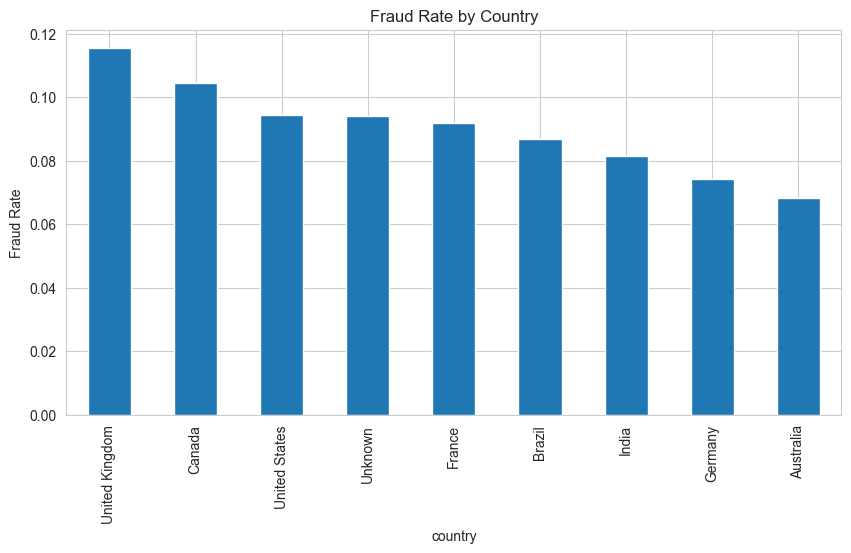

In [42]:
country_fraud[1].sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Fraud Rate by Country")
plt.ylabel("Fraud Rate")

plt.show()

Save Progress

In [43]:
fraud_df.to_csv(
    "../data/processed/fraud_with_country.csv",
    index=False
)

In [44]:
fraud_df['country'] = fraud_df['ip_address_int'].apply(get_country)

Convert IPs + Prepare Join

In [45]:
fraud_df['ip_address_int'] = fraud_df['ip_address'].astype('int64')

In [ ]:
ip_country_df

,lower_bound_ip_address,upper_bound_ip_address,country
0,100000000,149999999,United States
1,150000000,199999999,Canada
2,200000000,249999999,United Kingdom
3,250000000,299999999,Germany
4,300000000,349999999,France
5,350000000,399999999,Brazil
6,400000000,449999999,India
7,450000000,499999999,Australia


Sort IP Country Table

In [46]:
ip_country_df = ip_country_df.sort_values('lower_bound_ip_address')

Efficient Mapping

In [47]:
ip_country_df = ip_country_df.rename(columns={
    'lower_bound_ip_address': 'ip_lower',
    'upper_bound_ip_address': 'ip_upper'
})

Merge

In [48]:
fraud_df = fraud_df.sort_values('ip_address_int')
ip_country_df = ip_country_df.sort_values('ip_lower')

In [49]:
merged_df = pd.merge_asof(
    fraud_df,
    ip_country_df,
    left_on='ip_address_int',
    right_on='ip_lower',
    direction='backward'
)

Filter valid matches

In [50]:
merged_df = merged_df[
    merged_df['ip_address_int'] <= merged_df['ip_upper']
]

final dataset

In [51]:
fraud_df = merged_df.copy()

In [54]:
ip_country_df.columns

Index(['ip_lower', 'ip_upper', 'country'], dtype='str')

Replace function

In [55]:
def get_country(ip):
    match = ip_country_df[
        (ip_country_df['ip_lower'] <= ip) &
        (ip_country_df['ip_upper'] >= ip)
    ]
    
    if len(match) > 0:
        return match.iloc[0]['country']
    else:
        return "Unknown"

Apply mapping

In [56]:
fraud_df['country'] = fraud_df['ip_address_int'].apply(get_country)

Verify

In [57]:
fraud_df[['ip_address_int', 'country']].head()

,ip_address_int,country
3634,100042384,United States
3635,100064143,United States
3636,100095694,United States
3637,100189367,United States
3638,100197589,United States


Check distribution

In [58]:
fraud_df['country'].value_counts()

country
United Kingdom    1948
Australia         1855
India             1849
Brazil            1808
Canada            1798
United States     1768
Germany           1765
France            1751
Name: count, dtype: int64

Feature Engineering

Time-based Features

Hour of Day

In [60]:
fraud_df['hour_of_day'] = fraud_df['purchase_time'].dt.hour

Day of Week

In [61]:
fraud_df['day_of_week'] = fraud_df['purchase_time'].dt.dayofweek

Time Since Signup

In [62]:
fraud_df['time_since_signup'] = (
    fraud_df['purchase_time'] - fraud_df['signup_time']
).dt.total_seconds()

User Behavior Features

Transaction Count per User

In [63]:
fraud_df['transaction_count'] = fraud_df.groupby('user_id')['user_id'].transform('count')

Sort for time-based calculations

In [64]:
fraud_df = fraud_df.sort_values(['user_id', 'purchase_time'])

Time Between Transactions (Velocity)

In [65]:
fraud_df['time_between_transactions'] = fraud_df.groupby('user_id')['purchase_time'].diff().dt.total_seconds()

Fill first NaN values

In [66]:
fraud_df['time_between_transactions'] = fraud_df['time_between_transactions'].fillna(0)

Encode Country

In [67]:
fraud_df['country'].value_counts().head()

country
United Kingdom    1948
Australia         1855
India             1849
Brazil            1808
Canada            1798
Name: count, dtype: int64

(One-hot encoding)

In [68]:
fraud_df = pd.get_dummies(fraud_df, columns=['country'], drop_first=True)

Verify New Features

In [69]:
fraud_df[[
    'hour_of_day',
    'day_of_week',
    'time_since_signup',
    'transaction_count',
    'time_between_transactions'
]].head()

,hour_of_day,day_of_week,time_since_signup,transaction_count,time_between_transactions
12873,11,3,6667201.0,1,0.0
15712,18,3,4518193.0,1,0.0
11853,0,3,4971984.0,1,0.0
10673,7,5,1701001.0,1,0.0
10681,0,5,5847711.0,1,0.0


Save Feature Engineered Dataset

In [70]:
fraud_df.to_csv(
    "../data/processed/fraud_feature_engineered.csv",
    index=False
)

print("Feature engineering completed successfully")

Feature engineering completed successfully
